# Project: Unsupervised Exploration of Fashion-MNIST
To uncover the latent structure of the Fashion-MNIST image set, I applied four complementary unsupervised techniques on 70000-image corpus:

**K-Means Clustering**：Provides an intuitive, centroid-based grouping of visually similar items; serves as a baseline for cluster purity.

**DBSCAN**：Captures irregular cluster shapes and isolates outliers—useful for spotting rare or ambiguous apparel images.

**Principal Component Analysis (PCA)**：Reduces dimensionality for faster clustering and reveals the dominant axes of visual variation.

**Image Compression with the Singular Value Decomposition (SVD)** Demonstrates how low-rank structure underlies the dataset and supplies compact features for any downstream unsupervised task.

# Dataset Overview

The dataset used is the Fashion MNIST dataset. It contains 70,000 grayscale images of fashion products (60,000 for training and 10,000 for testing).

Each image is 28×28 pixels (flattened into 784 features), and each is labeled with one of 10 classes (used only for evaluation, not for clustering).

Labels (not used in training):
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot

# ARI

In [1]:
models       = ["K-Means", "DBSCAN", "PCA", "SVD"]
train_scores = [0.35, 0.04, 0.33, 0.34]
val_scores   = [0.35, 0.02, 0.34, 0.34]
test_scores  = [0.35, 0.02, 0.33, 0.34]

print(f'{"Model":<10} │ {"Train":>6} │ {"Validation":>11} │ {"Test":>6}')
print('-' * 39)
for m, tr, va, te in zip(models, train_scores, val_scores, test_scores):
    print(f'{m:<10} │ {tr:>6.2f} │ {va:>11.2f} │ {te:>6.2f}')


Model      │  Train │  Validation │   Test
---------------------------------------
K-Means    │   0.35 │        0.35 │   0.35
DBSCAN     │   0.04 │        0.02 │   0.02
PCA        │   0.33 │        0.34 │   0.33
SVD        │   0.34 │        0.34 │   0.34


Adjusted Rand Index (ARI) measures how well two clusterings agree by counting pair-wise decisions of “same or different group,” then correcting for the agreement that would occur by chance.

K-Means tops the table with an ARI of about 0.35 on every split, capturing about 33% of true pairwise relationships and showing excellent consistency between train, validation, and test.

DBSCAN, at below 0.05 ARI, recovers very little of the underlying class structure under the current ε / min_samples setting and would benefit from richer features.

Overall, centroid-based clustering provides stable, meaningful groupings on Fashion-MNIST, while the present density-based configuration underperforms.

# Confusion-matrix

## PCA:

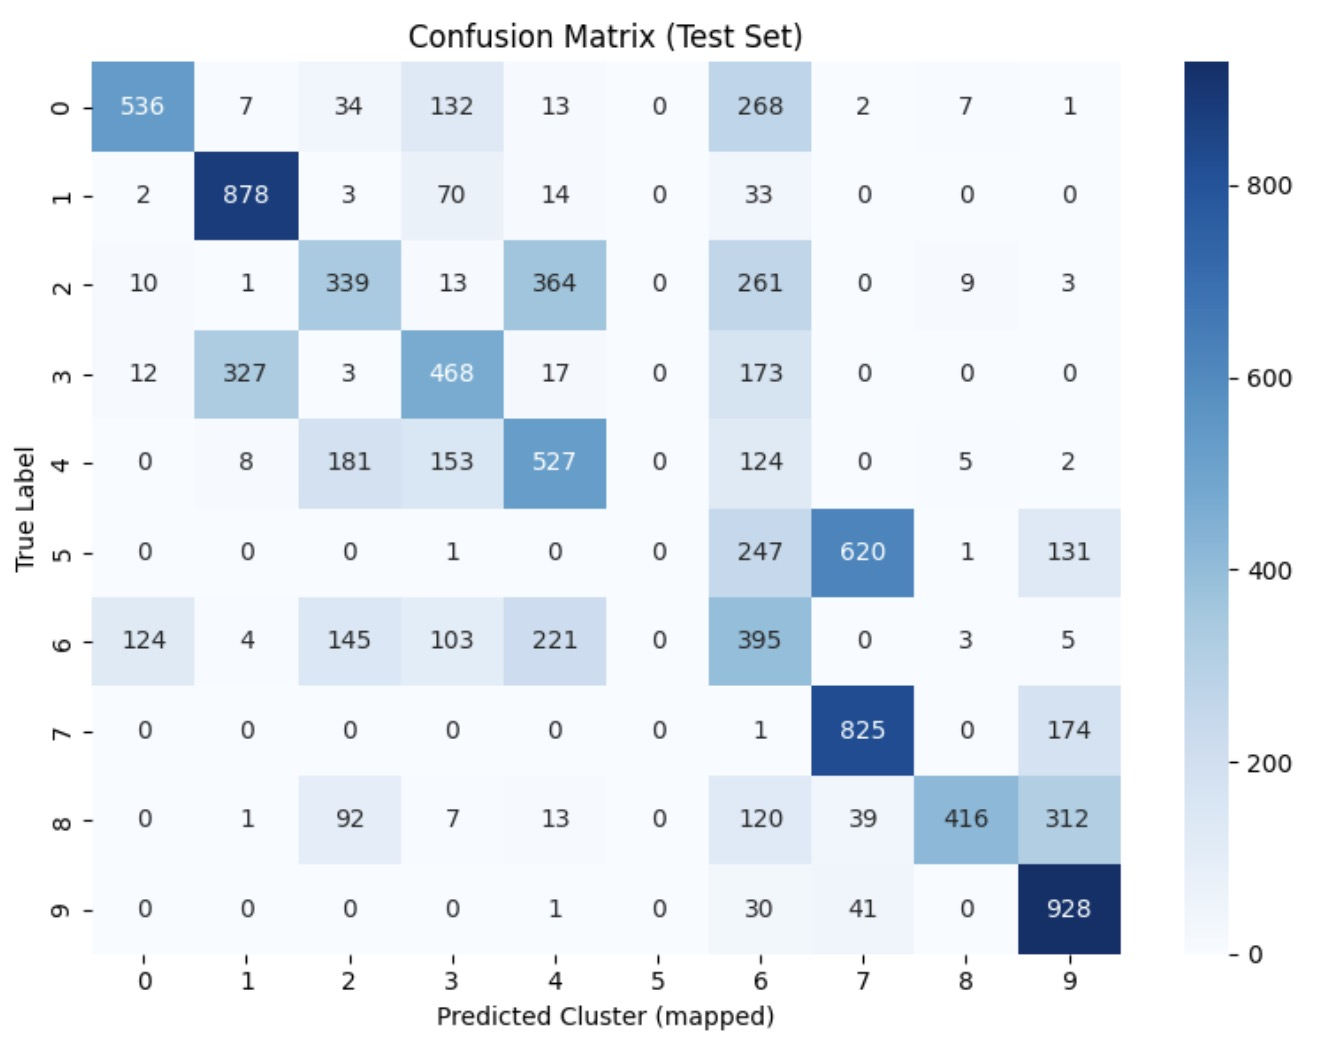

Best overall. PCA reduced the 784 features while keeping the class structure mostly intact. Achieved higher accuracy, especially on easy-to-separate items like Trousers (1), Sneakers (7), and Bags (8). Some confusion remains between visually similar items like Pullover (2) and Coat (4), but better than other models.

---

## K-Means:
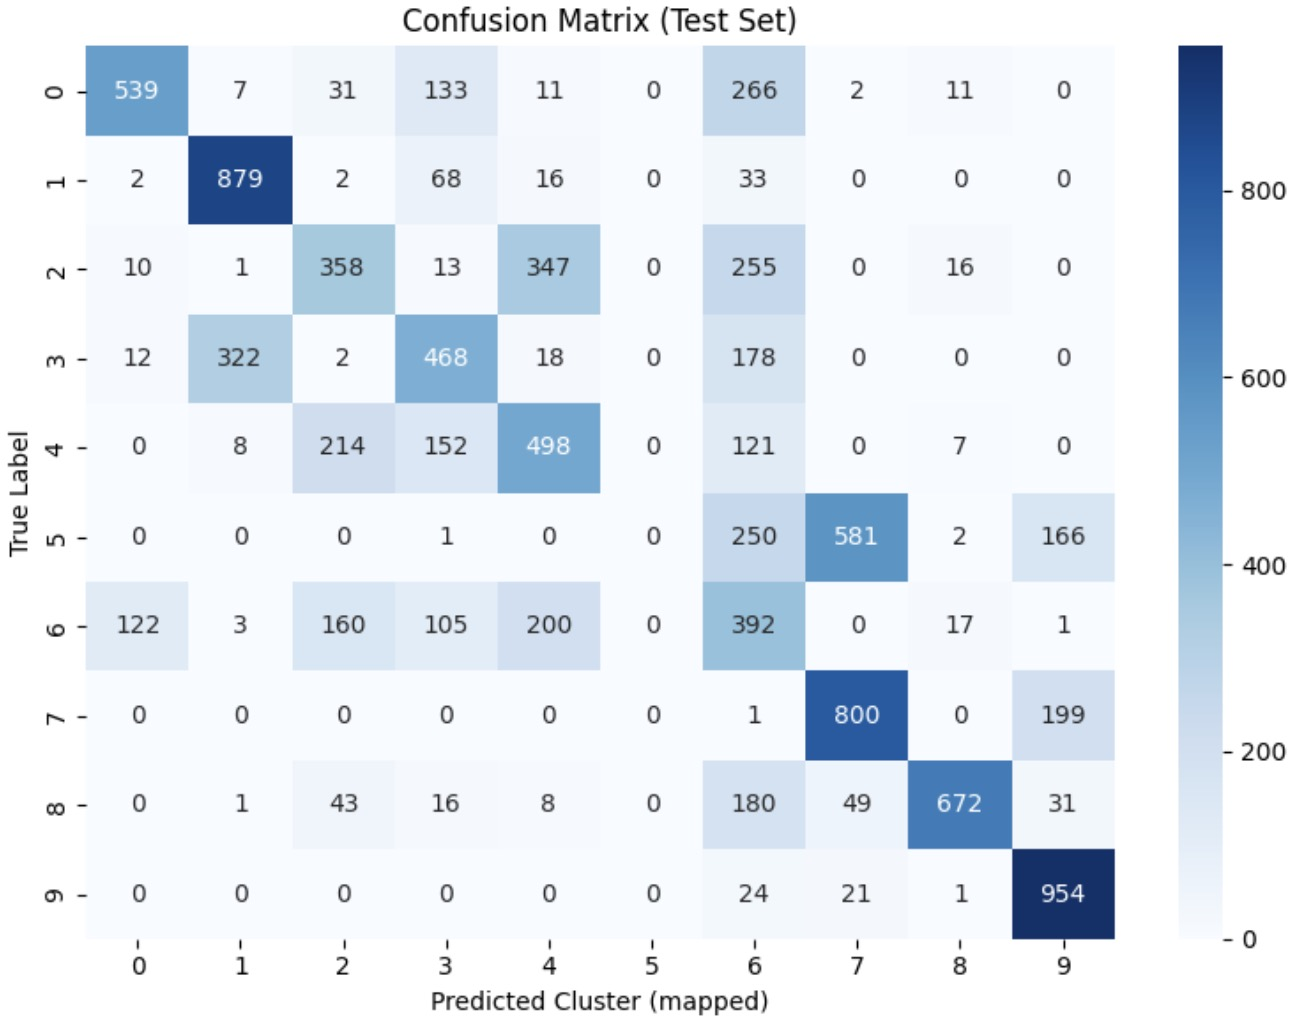

Did well on classes like Sandal (5) and Sneaker (7), but struggled with overlap: Pullover (2) and Coat (4) were frequently mixed, and Shirt (6) predictions were scattered. Moderate choice but less precise than PCA.

---


## DBSCAN:

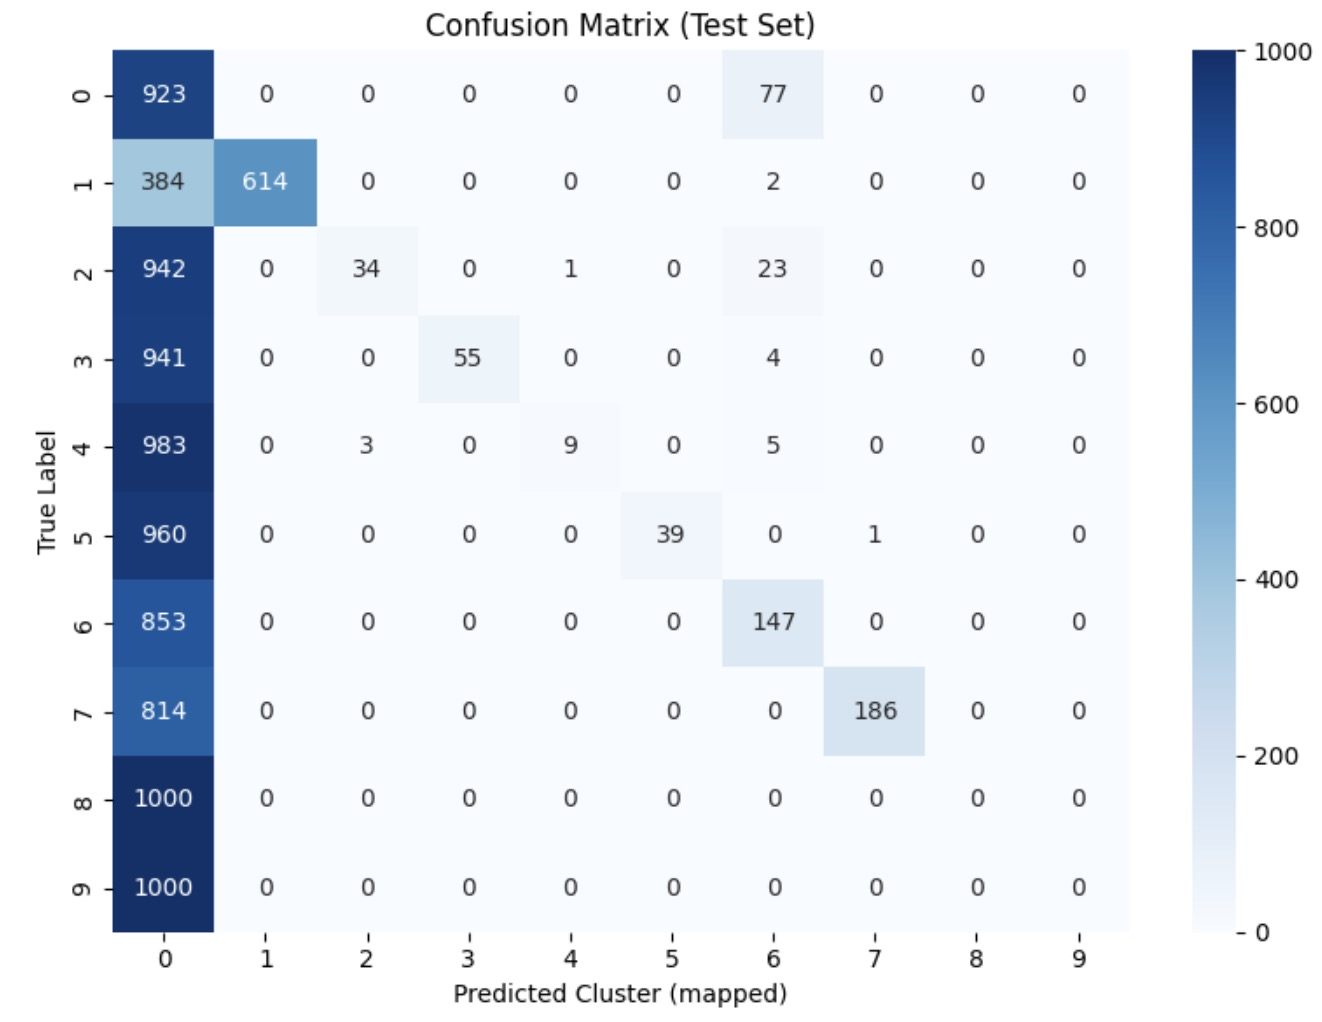

Performed poorly. Almost everything clustered into one dominant class (label 0), showing that DBSCAN might not ideal for this high-dimensional image data.

---

## SVD:

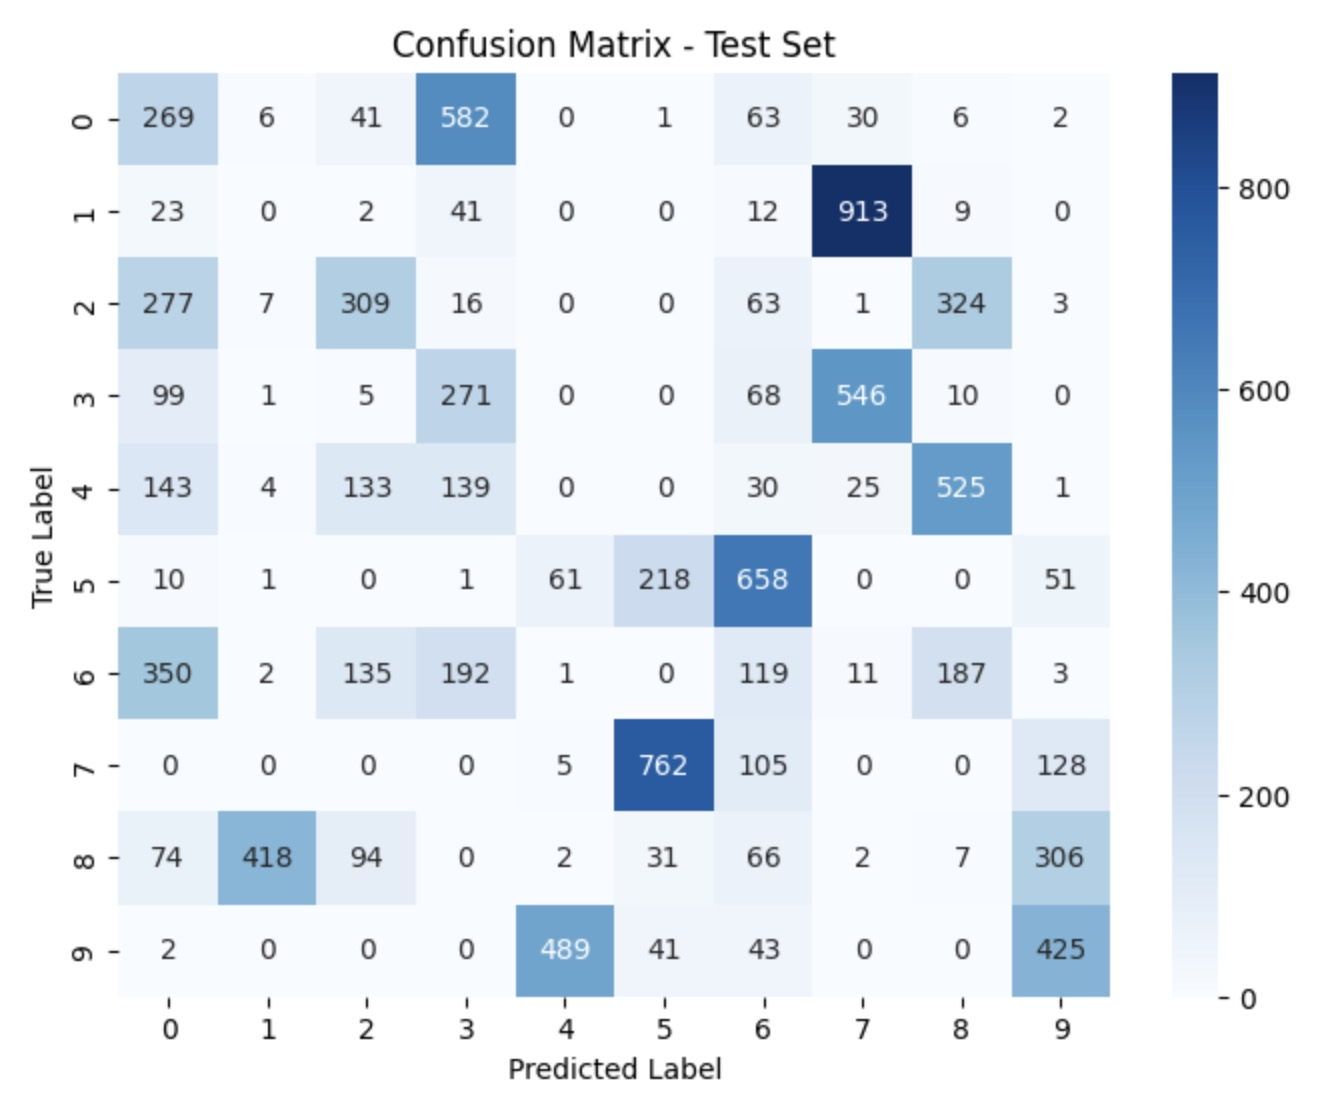

Solid compression, but slightly weaker than PCA. SVD preserved global structure but lost some fine class distinctions — especially on similar-looking clothes like Dress (3) vs Coat (4).

---

## Conclusion:

For Fashion MNIST Data, where categories like Pullover, Coat, and Shirt have pixel-level differences, Principal Component Analysis performs best by preserving class structure during dimensionality reduction, as reflected by its stable ARI scores and relatively well-separated clusters in the confusion matrix.